In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge


def generate_lorenz(T=3000, dt=0.01):
    x, y, z = 1.0, 1.0, 1.0
    out = np.zeros((T, 3))
    for t in range(T):
        dx = 10 * (y - x)
        dy = x * (28 - z) - y
        dz = x * y - (8/3) * z
        x += dt * dx
        y += dt * dy
        z += dt * dz
        out[t] = [x, y, z]
    return out


def make_W(N, J):
    return np.random.normal(0, J/np.sqrt(N), (N, N))

def make_Win(N):
    return np.random.uniform(-0.5, 0.5, (N, 3))

In [16]:
def run_reservoir(W, Win, U, eps=1e-2):
    T = len(U)
    N = W.shape[0]

    r = np.zeros(N)
    states = np.zeros((T, N))

    for t in range(T):
        u = U[t]
        r += eps * (-r + np.tanh(W @ r + Win @ u))
        states[t] = r

    return states


U = generate_lorenz(T=3000)
U = (U - U.mean(0)) / U.std(0)  

N = 200
W = make_W(N, J=1.2)
Win = make_Win(N)

states = run_reservoir(W, Win, U)


In [17]:
split = int(0.7 * len(U))

R_train = states[:split-1]
Y_train = U[1:split]

R_test = states[split-1:-1]
Y_test = U[split:]

model = Ridge(alpha=1e-4)
model.fit(R_train, Y_train)



,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",Non

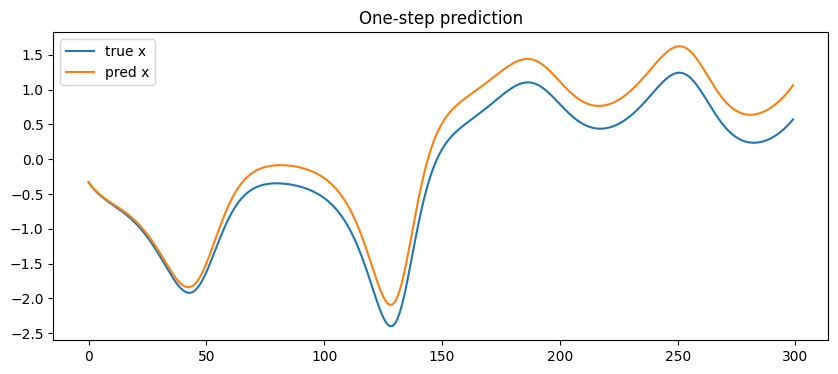

mean error: 5.866200828500154


In [18]:
preds = model.predict(R_test)

plt.figure(figsize=(10,4))
plt.plot(Y_test[:300,0], label="true x")
plt.plot(preds[:300,0], label="pred x")
plt.legend()
plt.title("One-step prediction")
plt.show()

error = np.linalg.norm(Y_test - preds, axis=1)
print("mean error:", error.mean())

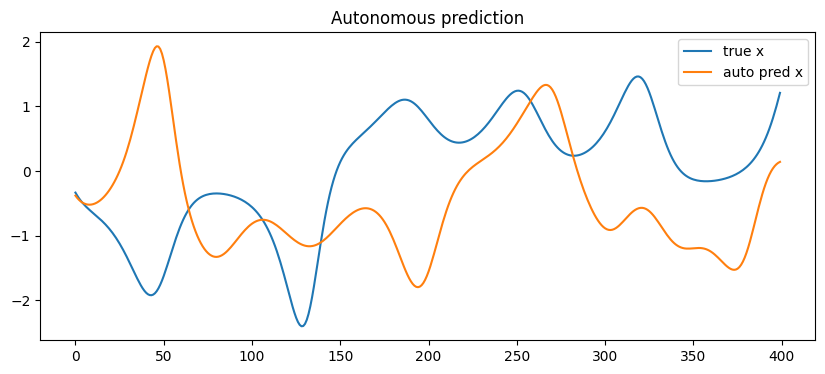

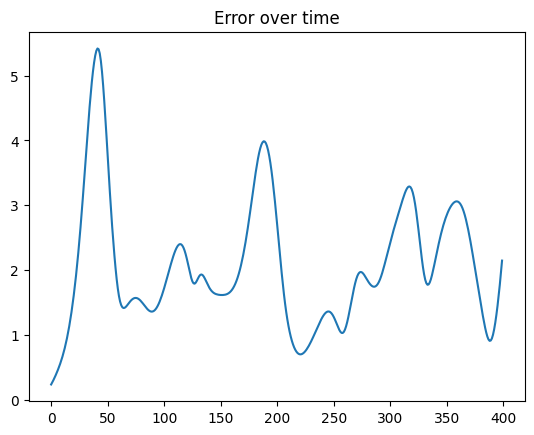

In [19]:
r = states[split-1].copy()
u = U[split-1].copy()

preds_auto = []

for _ in range(400):
    r += 1e-2 * (-r + np.tanh(W @ r + Win @ u))
    u = model.predict(r.reshape(1,-1))[0]
    preds_auto.append(u)

preds_auto = np.array(preds_auto)
true_future = U[split:split+400]

plt.figure(figsize=(10,4))
plt.plot(true_future[:,0], label="true x")
plt.plot(preds_auto[:,0], label="auto pred x")
plt.legend()
plt.title("Autonomous prediction")
plt.show()

err_auto = np.linalg.norm(true_future - preds_auto, axis=1)
plt.plot(err_auto)
plt.title("Error over time")
plt.show()